In [1]:
# ----------------------------------------------------------------
# 0. Colab setup and imports
# ----------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

import sys
sys.path.insert(0, '/content/drive/MyDrive/Vol_fitter')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, asdict
from scipy.optimize import minimize, lsq_linear
from scipy.interpolate import griddata
import plotly.graph_objects as go
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
pio.renderers.default = 'colab'

from volsurf.paths import PROJECT_ROOT, PROCESSED_DIR, FITTED_DIR, AUX_DIR

VOLSURF_PKG = PROJECT_ROOT / 'volsurf'

Mounted at /content/drive


In [2]:
# ----------------------------------------------------------------
# 1. Load the de-Americanised snapshot from notebook 02  [REPLACEMENT]
# ----------------------------------------------------------------
# Rename T -> tau at load to avoid clashing with DataFrame.T transpose.

SNAP_DATE = '2010-06-15'
snap = pd.read_parquet(PROCESSED_DIR / f'chain_{SNAP_DATE}.parquet')
snap = snap.rename(columns={'T': 'tau'})

# Total variance: w = iv^2 * tau
snap['w'] = snap.iv_mid ** 2 * snap.tau

# Sanity filter
snap = snap[snap.iv_mid.between(0.05, 2.0) & snap.k.between(-0.5, 0.3)]

print(f'Loaded {len(snap):,} quotes across {snap.expiry.nunique()} expiries')
print(f'  S = {snap.S.iloc[0]:.2f}, snapshot date = {SNAP_DATE}')
print(f'  tau range: {snap.tau.min():.4f} to {snap.tau.max():.4f} years')
print(f'  Columns: {list(snap.columns)}')

Loaded 674 quotes across 15 expiries
  S = 111.98, snapshot date = 2010-06-15
  tau range: 0.0082 to 2.5207 years
  Columns: ['date', 'expiry', 'tau', 'r', 'F', 'q', 'q_implied', 'D', 'n_iter', 'n_valid', 'strike', 'k', 'iv_call', 'iv_put', 'iv_mid', 'S', 'w']


In [3]:
# ----------------------------------------------------------------
# 2. SVI raw parameterisation and analytic derivatives
# ----------------------------------------------------------------
# Gatheral (2004) raw form:
#   w(k) = a + b * (rho * (k - m) + sqrt((k - m)^2 + sigma^2))
# Parameter constraints during calibration:
#   b >= 0, sigma > 0, |rho| < 1
# Sufficient non-negativity: a + b*sigma*sqrt(1 - rho^2) >= 0
# Roger Lee wing bound: b*(1 + |rho|) <= 4/T

@dataclass(frozen=True)
class SVIParams:
    a: float
    b: float
    rho: float
    m: float
    sigma: float

def svi_w(k, p):
    """Total implied variance under SVI raw."""
    return p.a + p.b * (p.rho * (k - p.m) + np.sqrt((k - p.m) ** 2 + p.sigma ** 2))

def svi_dw_dk(k, p):
    """First derivative of total variance with respect to log-moneyness."""
    return p.b * (p.rho + (k - p.m) / np.sqrt((k - p.m) ** 2 + p.sigma ** 2))

def svi_d2w_dk2(k, p):
    """Second derivative of total variance with respect to log-moneyness."""
    return p.b * p.sigma ** 2 / ((k - p.m) ** 2 + p.sigma ** 2) ** 1.5

def svi_iv(k, T, p):
    """SVI implied volatility at log-moneyness k and maturity T."""
    return np.sqrt(svi_w(k, p) / T)

# Smoke test with the Axel Vogt parameter set from Gatheral-Jacquier (2014)
vogt = SVIParams(a=-0.0410, b=0.1331, rho=0.3060, m=0.3586, sigma=0.4153)
k_test = np.linspace(-1, 1, 5)
print('Axel Vogt parameter set, total variance values:')
print(f'  k = {k_test}')
print(f'  w(k) = {svi_w(k_test, vogt)}')

Axel Vogt parameter set, total variance values:
  k = [-1.  -0.5  0.   0.5  1. ]
  w(k) = [0.09275565 0.05097657 0.01742625 0.02315157 0.08682671]


In [4]:
# ----------------------------------------------------------------
# 3. Zeliade quasi-explicit calibration
# ----------------------------------------------------------------
# Substitution y = (k - m) / sigma renders the SVI formula linear in
# transformed parameters (a, d, c) where d = rho*b*sigma, c = b*sigma:
#   w(k) = a + d*y + c*sqrt(y^2 + 1)
# For each (m, sigma) the inner problem is constrained linear LS; the
# outer is a 2D Nelder-Mead. Reference: De Marco and Martini, Zeliade
# White Paper ZWP-0005 (2009).

def initial_guess(k, w):
    """Sensible starting point for the (m, sigma) outer search."""
    i_min = np.argmin(w)
    m0 = float(k[i_min])
    sigma0 = max(0.05, (k.max() - k.min()) / 4)
    return m0, sigma0

def fit_svi_slice(k, w_market, T, weights=None, initial=None,
                  m_bounds=(-0.3, 0.3), sigma_bounds=(0.01, 0.5),
                  enforce_negative_rho=True):
    k = np.asarray(k, dtype=float)
    w_market = np.asarray(w_market, dtype=float)
    weights = np.ones_like(w_market) if weights is None else np.asarray(weights, dtype=float)
    sqrt_w = np.sqrt(weights)

    def inner_solve(m, sigma):
        y = (k - m) / sigma
        A = np.column_stack([np.ones_like(y), y, np.sqrt(y * y + 1)])
        d_upper = 0.0 if enforce_negative_rho else np.inf
        bounds = (np.array([-np.inf, -np.inf, 0.0]),
                  np.array([np.inf, d_upper, 4.0 * sigma]))
        try:
            res = lsq_linear(sqrt_w[:, None] * A, sqrt_w * w_market,
                             bounds=bounds, method='trf', max_iter=200)
            a, d, c = res.x
        except Exception:
            return np.inf, 0.0, 0.0, 0.0
        b = c / sigma
        rho = d / c if abs(c) > 1e-12 else 0.0
        rho = float(np.clip(rho, -0.999, 0.999))
        w_model = a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))
        return float(np.sum(weights * (w_model - w_market) ** 2)), a, b, rho

    def objective(x):
        m, sigma = x
        if not (m_bounds[0] <= m <= m_bounds[1] and sigma_bounds[0] <= sigma <= sigma_bounds[1]):
            return 1e10
        return inner_solve(m, sigma)[0]

    # Build start grid: warm start (if given) plus a small fixed grid
    starts = []
    if initial is not None:
        m0 = float(np.clip(initial.m, m_bounds[0], m_bounds[1]))
        s0 = float(np.clip(initial.sigma, sigma_bounds[0], sigma_bounds[1]))
        starts.append((m0, s0))
    for m0 in (-0.05, 0.0, 0.05):
        for s0 in (0.05, 0.15, 0.30):
            starts.append((m0, s0))

    best_rss, best_params = np.inf, None
    for m_start, s_start in starts:
        try:
            res = minimize(objective, [m_start, s_start], method='Nelder-Mead',
                           options={'xatol': 1e-7, 'fatol': 1e-12, 'maxiter': 500})
            m_opt = float(np.clip(res.x[0], m_bounds[0], m_bounds[1]))
            sigma_opt = float(np.clip(res.x[1], sigma_bounds[0], sigma_bounds[1]))
            rss, a, b, rho = inner_solve(m_opt, sigma_opt)
            if rss < best_rss:
                best_rss = rss
                best_params = SVIParams(a=float(a), b=float(b), rho=float(rho),
                                          m=m_opt, sigma=sigma_opt)
        except Exception:
            continue

    if best_params is None:
        raise RuntimeError('all multi-start fits failed')
    return best_params, best_rss

    def objective(x):
        m, sigma = x
        if not (m_bounds[0] <= m <= m_bounds[1] and sigma_bounds[0] <= sigma <= sigma_bounds[1]):
            return 1e10
        rss, *_ = inner_solve(m, sigma)
        return rss

    m0, sigma0 = initial_guess(k, w_market) if initial is None else (initial.m, initial.sigma)
    res = minimize(objective, [m0, sigma0], method='Nelder-Mead',
                   options={'xatol': 1e-7, 'fatol': 1e-12, 'maxiter': 500})
    m_opt, sigma_opt = res.x
    sigma_opt = float(np.clip(sigma_opt, sigma_bounds[0], sigma_bounds[1]))
    rss, a, b, rho = inner_solve(m_opt, sigma_opt)
    params = SVIParams(a=float(a), b=float(b), rho=float(rho), m=float(m_opt), sigma=float(sigma_opt))

    if verbose:
        print(f'  a={a:+.4f}  b={b:+.4f}  rho={rho:+.3f}  m={m_opt:+.4f}  '
              f'sigma={sigma_opt:.4f}  RSS={rss:.3e}')
    return params, rss

Fitting expiry 2010-12-31, T=0.5453y, 79 quotes


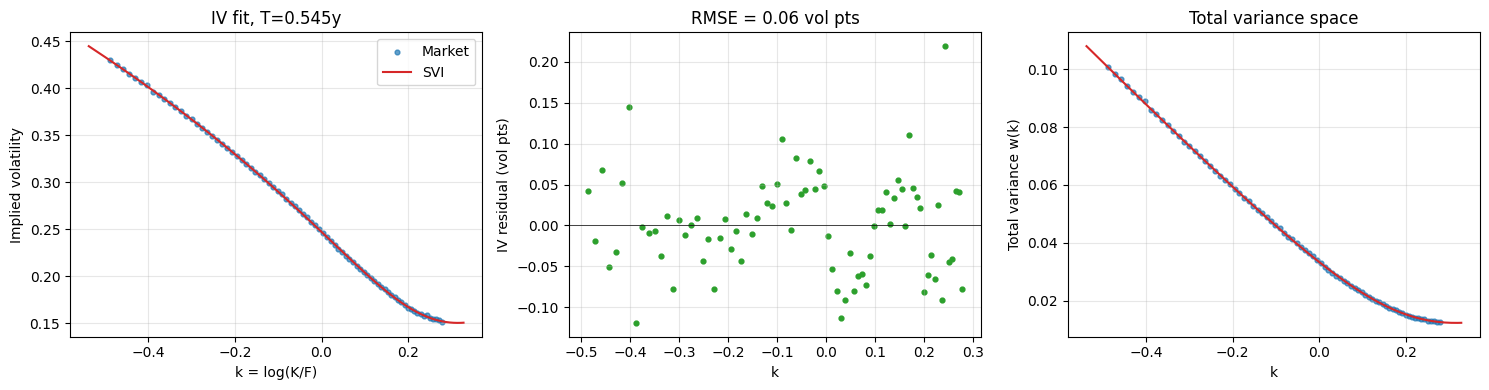

In [5]:
# ----------------------------------------------------------------
# 4. Fit one slice, visualise  [REPLACEMENT]
# ----------------------------------------------------------------
expiries_sorted = sorted(snap.expiry.unique(),
                          key=lambda e: snap[snap.expiry == e].tau.iloc[0])
mid_expiry = expiries_sorted[len(expiries_sorted) // 2]
slice_df = snap[snap.expiry == mid_expiry].sort_values('k').reset_index(drop=True)
T_one = float(slice_df.tau.iloc[0])

print(f'Fitting expiry {mid_expiry.date()}, T={T_one:.4f}y, {len(slice_df)} quotes')
params_one, rss_one = fit_svi_slice(slice_df.k.values, slice_df.w.values, T_one)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_grid = np.linspace(slice_df.k.min() - 0.05, slice_df.k.max() + 0.05, 300)

axes[0].scatter(slice_df.k, slice_df.iv_mid, s=12, alpha=0.7, label='Market', color='C0')
axes[0].plot(k_grid, np.sqrt(svi_w(k_grid, params_one) / T_one), 'C3-', lw=1.5, label='SVI')
axes[0].set(xlabel='k = log(K/F)', ylabel='Implied volatility',
            title=f'IV fit, T={T_one:.3f}y')
axes[0].legend(); axes[0].grid(alpha=0.3)

iv_model = np.sqrt(svi_w(slice_df.k.values, params_one) / T_one)
resid_pct = (slice_df.iv_mid.values - iv_model) * 100
axes[1].scatter(slice_df.k, resid_pct, s=12, color='C2')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set(xlabel='k', ylabel='IV residual (vol pts)',
            title=f'RMSE = {resid_pct.std():.2f} vol pts')
axes[1].grid(alpha=0.3)

axes[2].scatter(slice_df.k, slice_df.w, s=12, alpha=0.7, color='C0')
axes[2].plot(k_grid, svi_w(k_grid, params_one), 'C3-', lw=1.5)
axes[2].set(xlabel='k', ylabel='Total variance w(k)', title='Total variance space')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [6]:
import time

def fit_all_slices(snap_df, min_quotes=10, verbose=False):
    fits = {}
    prev_params = None
    expiries_by_T = sorted(snap_df.expiry.unique(),
                            key=lambda e: snap_df[snap_df.expiry == e].tau.iloc[0])
    for expiry in expiries_by_T:
        sdf = snap_df[snap_df.expiry == expiry].sort_values('k').reset_index(drop=True)
        if len(sdf) < min_quotes: continue
        T = float(sdf.tau.iloc[0])
        try:
            params, rss = fit_svi_slice(sdf.k.values, sdf.w.values, T,
                                         initial=prev_params)
            iv_model = np.sqrt(svi_w(sdf.k.values, params) / T)
            rmse = float(np.sqrt(np.mean((sdf.iv_mid.values - iv_model) ** 2)))
            fits[expiry] = {
                'T': T, 'params': params, 'rss_w': rss, 'rmse_iv': rmse,
                'n_quotes': len(sdf), 'forward': float(sdf.F.iloc[0]),
            }
            prev_params = params
            if verbose:
                print(f'  T={T:.4f}: rho={params.rho:+.3f}, RMSE={rmse*100:.2f}vp, n={len(sdf)}')
        except Exception as exc:
            print(f'FAIL {expiry.date()}: {exc}')
    return fits

t0 = time.time()
fits = fit_all_slices(snap, min_quotes=10, verbose=True)
print(f'\nFitted {len(fits)} slices in {time.time() - t0:.1f}s')

summary = pd.DataFrame([
    {'expiry': e, 'T': f['T'], 'F': f['forward'],
     'a': f['params'].a, 'b': f['params'].b, 'rho': f['params'].rho,
     'm': f['params'].m, 'sigma': f['params'].sigma,
     'rmse_vp': f['rmse_iv'] * 100, 'n': f['n_quotes']}
    for e, f in fits.items()
]).sort_values('T')
print('\nFit summary:')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

  T=0.0082: rho=-0.000, RMSE=1.89vp, n=22
  T=0.0411: rho=-0.728, RMSE=0.54vp, n=31
  T=0.0849: rho=-0.000, RMSE=0.32vp, n=48
  T=0.1808: rho=-0.000, RMSE=0.17vp, n=62
  T=0.2575: rho=-0.000, RMSE=0.18vp, n=67
  T=0.2932: rho=-0.000, RMSE=0.16vp, n=66
  T=0.5070: rho=-0.000, RMSE=0.09vp, n=77
  T=0.5453: rho=-0.350, RMSE=0.06vp, n=79
  T=0.7562: rho=-0.999, RMSE=0.05vp, n=82
  T=0.7918: rho=-0.410, RMSE=0.04vp, n=59
  T=1.0055: rho=-0.999, RMSE=0.05vp, n=16
  T=1.5042: rho=-0.999, RMSE=0.06vp, n=16
  T=1.5426: rho=-0.999, RMSE=0.02vp, n=17
  T=1.6001: rho=-0.999, RMSE=0.05vp, n=16
  T=2.5207: rho=-0.999, RMSE=0.07vp, n=16

Fitted 15 slices in 27.3s

Fit summary:
    expiry      T        F       a      b     rho       m  sigma  rmse_vp  n
2010-06-18 0.0082 111.6617 -0.0194 0.0746 -0.0000  0.0224 0.2656   1.8889 22
2010-06-30 0.0411 111.5149 -0.0275 0.0865 -0.7281 -0.3000 0.4717   0.5371 31
2010-07-16 0.0849 111.3957 -0.0164 0.0724 -0.0002  0.1290 0.2572   0.3196 48
2010-08-20 0.1808 111

In [7]:
# ----------------------------------------------------------------
# 6. Arbitrage diagnostics
# ----------------------------------------------------------------
# Two checks. Butterfly via the Durrleman g function (must be >= 0 for
# every slice). Calendar via monotonicity of w(k, T) in T at fixed k
# (between adjacent slices).

def durrleman_g(k, p):
    """Durrleman g function. Non-negative iff slice is butterfly-arb-free."""
    w = svi_w(k, p)
    wp = svi_dw_dk(k, p)
    wpp = svi_d2w_dk2(k, p)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2

def risk_neutral_density(k, p):
    """Risk-neutral density of log-forward from SVI slice."""
    w = svi_w(k, p)
    g = durrleman_g(k, p)
    d2 = -k / np.sqrt(w) - np.sqrt(w) / 2
    return g * np.exp(-d2 ** 2 / 2) / np.sqrt(2 * np.pi * w)

# Per-slice butterfly check
print('Butterfly check (g(k) >= 0 on grid k in [-3, 3]):')
print(f'{"T":>8} {"g_min":>12} {"n_violations":>14} {"max_density":>14}')
k_check = np.linspace(-3.0, 3.0, 1000)
butterfly_issues = []
for expiry, f in sorted(fits.items(), key=lambda x: x[1]['T']):
    g = durrleman_g(k_check, f['params'])
    g_min = float(g.min())
    n_viol = int((g < -1e-6).sum())
    rho = risk_neutral_density(k_check, f['params'])
    print(f'{f["T"]:>8.4f} {g_min:>+12.4e} {n_viol:>14d} {rho.max():>+14.4e}')
    if n_viol > 0:
        butterfly_issues.append((expiry, n_viol))

# Calendar check on a tight grid
print('\nCalendar check (w_long(k) >= w_short(k) for adjacent slices):')
k_cal = np.linspace(-0.5, 0.3, 200)
sorted_fits = sorted(fits.items(), key=lambda x: x[1]['T'])
calendar_issues = []
for i in range(len(sorted_fits) - 1):
    e_s, f_s = sorted_fits[i]
    e_l, f_l = sorted_fits[i + 1]
    w_s = svi_w(k_cal, f_s['params'])
    w_l = svi_w(k_cal, f_l['params'])
    xings = int((w_l < w_s - 1e-8).sum())
    if xings > 0:
        calendar_issues.append((f_s['T'], f_l['T'], xings))
        print(f'  T={f_s["T"]:.4f} -> T={f_l["T"]:.4f}: {xings} k-grid crossings')
if not calendar_issues:
    print('  Clean. No calendar arbitrage between adjacent slices.')

Butterfly check (g(k) >= 0 on grid k in [-3, 3]):
       T        g_min   n_violations    max_density
  0.0082  -1.6706e-02             38    +2.0378e+01
  0.0411  -4.2494e-03             41    +1.0144e+01
  0.0849  -2.3220e-02             51    +7.5555e+00
  0.1808  -3.3047e-02             91    +5.2947e+00
  0.2575  -3.9731e-02             81    +4.4844e+00
  0.2932  -4.1377e-02             84    +4.2182e+00
  0.5070  -4.4857e-02             83    +3.1658e+00
  0.5453  +4.4375e-02              0    +3.0727e+00
  0.7562  +2.7409e-01              0    +2.6148e+00
  0.7918  +4.7546e-02              0    +2.4985e+00
  1.0055  +2.7962e-01              0    +2.2607e+00
  1.5042  +2.8659e-01              0    +1.7970e+00
  1.5426  +2.7763e-01              0    +1.7126e+00
  1.6001  +2.9030e-01              0    +1.7254e+00
  2.5207  +2.9927e-01              0    +1.3680e+00

Calendar check (w_long(k) >= w_short(k) for adjacent slices):
  T=0.0082 -> T=0.0411: 54 k-grid crossings
  T=0.0849 

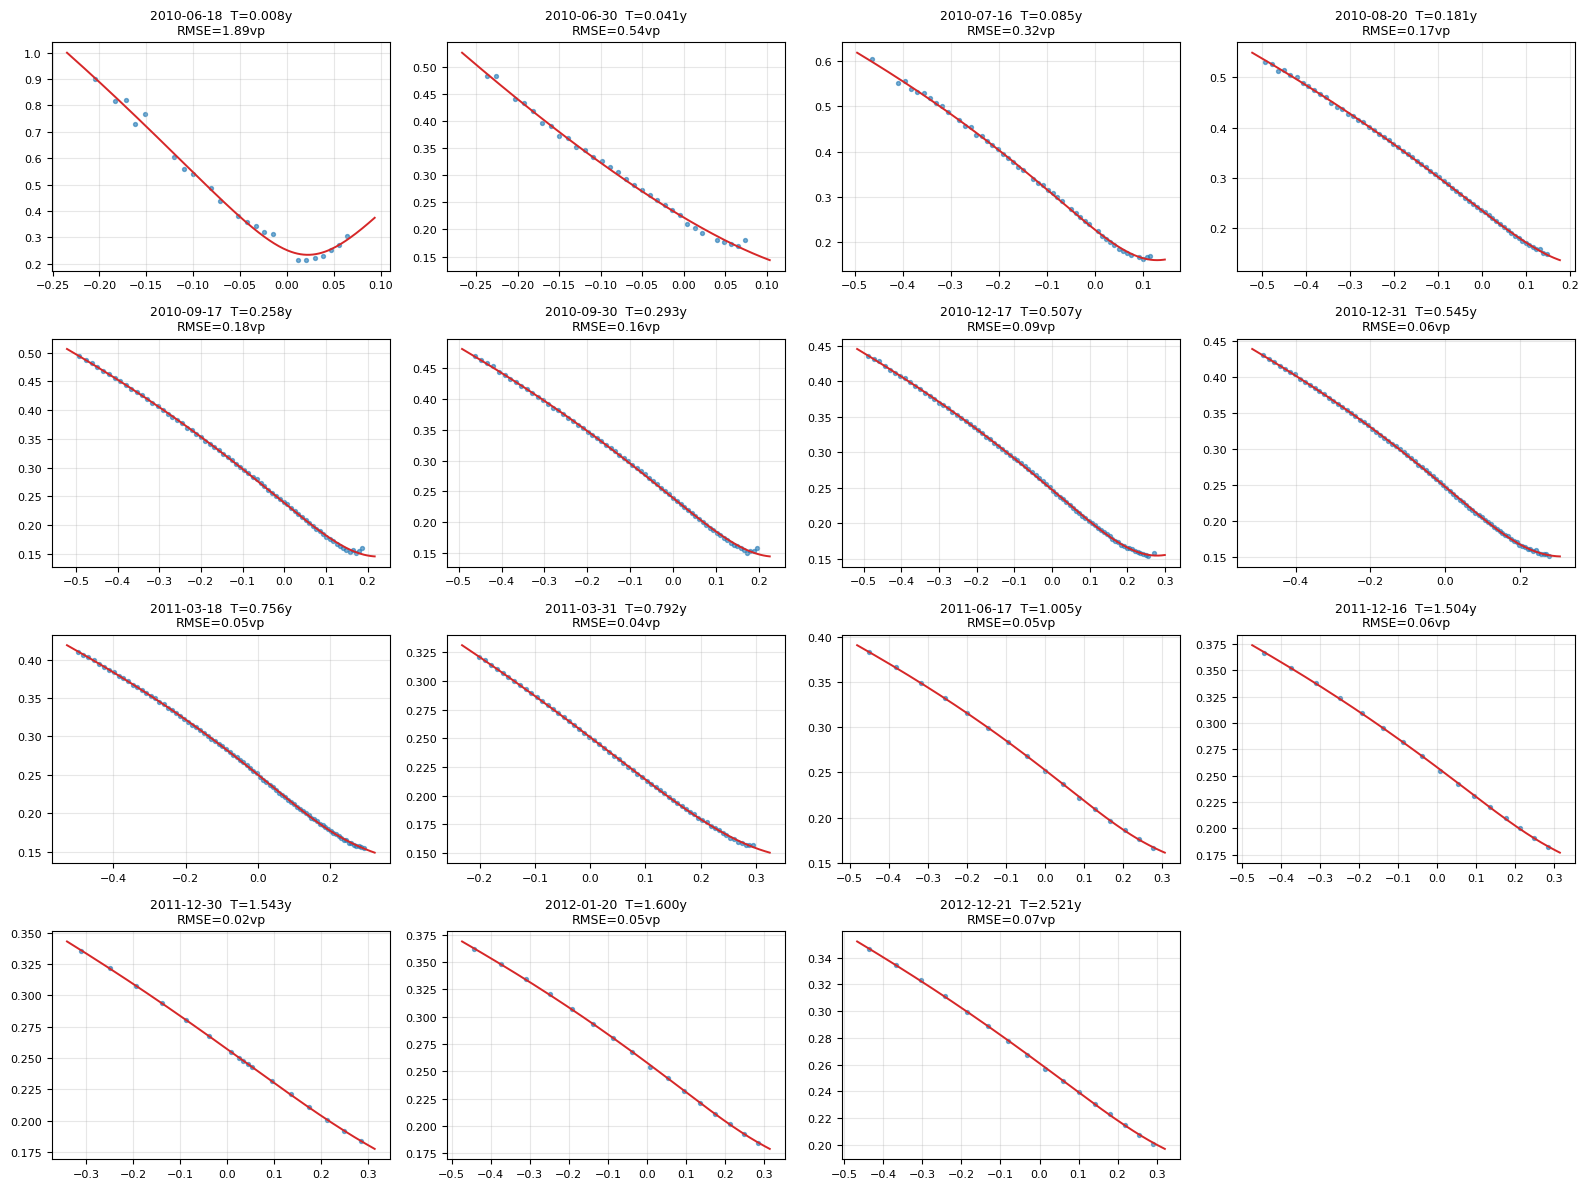

In [8]:
# ----------------------------------------------------------------
# 7. Per-slice fit grid plot
# ----------------------------------------------------------------
n_slices = len(fits)
n_cols = 4
n_rows = (n_slices + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, (expiry, f) in enumerate(sorted(fits.items(), key=lambda x: x[1]['T'])):
    ax = axes[i]
    sdf = snap[snap.expiry == expiry].sort_values('k')
    p = f['params']
    k_g = np.linspace(sdf.k.min() - 0.03, sdf.k.max() + 0.03, 200)
    iv_fit = np.sqrt(svi_w(k_g, p) / f['T'])
    ax.scatter(sdf.k, sdf.iv_mid, s=8, alpha=0.6, color='C0')
    ax.plot(k_g, iv_fit, 'C3-', lw=1.4)
    ax.set_title(f'{expiry.date()}  T={f["T"]:.3f}y\nRMSE={f["rmse_iv"]*100:.2f}vp', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

# Hide unused panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(); plt.show()

In [9]:
# ----------------------------------------------------------------
# 8. 3D fitted surface plot  [REPLACEMENT]
# ----------------------------------------------------------------
k_axis = np.linspace(-0.5, 0.3, 100)
T_axis = np.linspace(min(f['T'] for f in fits.values()),
                     max(f['T'] for f in fits.values()), 80)
IV_grid = np.full((len(T_axis), len(k_axis)), np.nan)

sorted_fits = sorted(fits.items(), key=lambda x: x[1]['T'])
Ts_known = np.array([f['T'] for _, f in sorted_fits])
W_known = np.array([svi_w(k_axis, f['params']) for _, f in sorted_fits])

for i_T, T_val in enumerate(T_axis):
    w_interp = np.array([np.interp(T_val, Ts_known, W_known[:, j])
                          for j in range(len(k_axis))])
    IV_grid[i_T] = np.sqrt(w_interp / T_val)

fig = go.Figure()
fig.add_trace(go.Surface(x=k_axis, y=T_axis, z=IV_grid,
                          colorscale='Viridis', colorbar=dict(title='IV'),
                          opacity=0.92,
                          contours={'z': {'show': True, 'usecolormap': True}}))
fig.add_trace(go.Scatter3d(x=snap.k, y=snap.tau, z=snap.iv_mid,
                            mode='markers',
                            marker=dict(size=2, color='black', opacity=0.5),
                            name='De-Americanised quotes'))
fig.update_layout(
    title=f'SPY fitted SVI surface, {SNAP_DATE}',
    scene=dict(xaxis_title='k = log(K/F)', yaxis_title='T (years)',
                zaxis_title='Implied volatility',
                camera=dict(eye=dict(x=1.6, y=-1.6, z=1.0)),
                aspectratio=dict(x=1.2, y=1.2, z=0.8)),
    width=950, height=700, margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

Synthetic SVI recovery:
                 True  Recovered     AbsErr
      a:    +0.0400    +0.0328   7.17e-03
      b:    +0.4000    +0.4185   1.85e-02
    rho:    -0.7000    -0.6666   3.34e-02
      m:    +0.0000    -0.0002   2.40e-04
  sigma:    +0.1000    +0.1129   1.29e-02


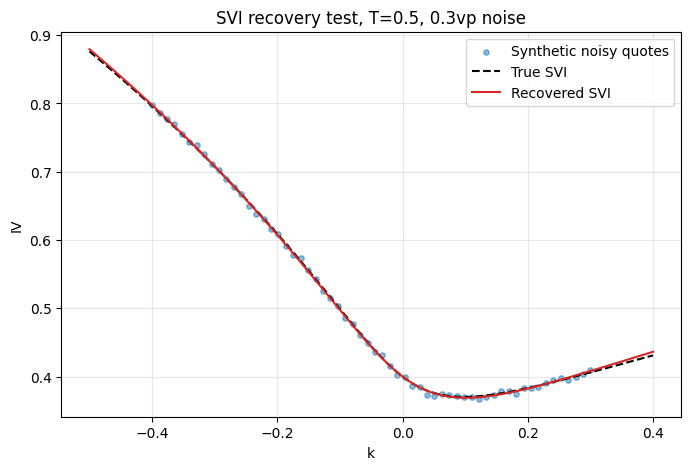

In [10]:
# ----------------------------------------------------------------
# 9. Synthetic round-trip validation
# ----------------------------------------------------------------
# Generate quotes from a known SVI parameter set, add realistic noise,
# fit, recover. Catches any systematic bias in the calibration.

np.random.seed(42)
true_params = SVIParams(a=0.04, b=0.40, rho=-0.7, m=0.0, sigma=0.10)
T_test = 0.5

k_synth = np.linspace(-0.4, 0.3, 60)
iv_true = np.sqrt(svi_w(k_synth, true_params) / T_test)
iv_noisy = iv_true + np.random.normal(0, 0.003, size=len(k_synth))  # 0.3 vol-pt noise
w_noisy = iv_noisy ** 2 * T_test

recovered, _ = fit_svi_slice(k_synth, w_noisy, T_test)

print('Synthetic SVI recovery:')
print(f'           {"True":>10} {"Recovered":>10} {"AbsErr":>10}')
for attr in ['a', 'b', 'rho', 'm', 'sigma']:
    t = getattr(true_params, attr)
    r = getattr(recovered, attr)
    print(f'  {attr:>5}: {t:>+10.4f} {r:>+10.4f} {abs(t - r):>10.2e}')

fig, ax = plt.subplots(figsize=(8, 5))
k_plot = np.linspace(-0.5, 0.4, 200)
ax.scatter(k_synth, iv_noisy, s=15, alpha=0.5, label='Synthetic noisy quotes')
ax.plot(k_plot, np.sqrt(svi_w(k_plot, true_params) / T_test), 'k--', lw=1.5, label='True SVI')
ax.plot(k_plot, np.sqrt(svi_w(k_plot, recovered) / T_test), 'C3-', lw=1.5, label='Recovered SVI')
ax.set(xlabel='k', ylabel='IV', title=f'SVI recovery test, T={T_test}, 0.3vp noise')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [11]:
# ----------------------------------------------------------------
# 10. Minimal Surface class (per-slice SVI, linear interp in T)
# ----------------------------------------------------------------
# Phase 1 surface: piecewise SVI in k, linear interpolation in total
# variance across T. Replaced in notebook 04 with proper SSVI (which
# satisfies calendar arbitrage by construction).

class SVISurface:
    """Collection of per-expiry SVI fits."""

    def __init__(self, fits_by_expiry, S, snapshot_date):
        self.fits = fits_by_expiry
        self.S = S
        self.snapshot_date = snapshot_date
        self._sorted = sorted(fits_by_expiry.items(), key=lambda kv: kv[1]['T'])
        self._Ts = np.array([f['T'] for _, f in self._sorted])
        self._params = [f['params'] for _, f in self._sorted]
        self._forwards = [f['forward'] for _, f in self._sorted]

    def total_variance(self, k, T):
        """w(k, T) via linear interp in total variance across fitted Ts."""
        k = np.asarray(k, dtype=float)
        if T <= self._Ts[0]:
            return svi_w(k, self._params[0]) * T / self._Ts[0]
        if T >= self._Ts[-1]:
            return svi_w(k, self._params[-1]) * T / self._Ts[-1]
        i = int(np.searchsorted(self._Ts, T) - 1)
        w_lo = svi_w(k, self._params[i])
        w_hi = svi_w(k, self._params[i + 1])
        t = (T - self._Ts[i]) / (self._Ts[i + 1] - self._Ts[i])
        return (1 - t) * w_lo + t * w_hi

    def iv(self, k, T):
        return np.sqrt(self.total_variance(k, T) / T)

    def density(self, k, T):
        """Density at the nearest fitted maturity (no cross-T interpolation)."""
        i = int(np.argmin(np.abs(self._Ts - T)))
        return risk_neutral_density(k, self._params[i])

    def __repr__(self):
        return (f'<SVISurface date={self.snapshot_date} S={self.S:.2f} '
                f'slices={len(self._Ts)} T=[{self._Ts.min():.3f}, {self._Ts.max():.3f}]>')

surface = SVISurface(fits, S=float(snap.S.iloc[0]), snapshot_date=pd.Timestamp(SNAP_DATE))
print(repr(surface))
print(f'  ATM IV(T=0.10): {surface.iv(0.0, 0.10):.4f}')
print(f'  ATM IV(T=0.25): {surface.iv(0.0, 0.25):.4f}')
print(f'  ATM IV(T=0.50): {surface.iv(0.0, 0.50):.4f}')
print(f'  ATM IV(T=1.00): {surface.iv(0.0, 1.00):.4f}')

<SVISurface date=2010-06-15 00:00:00 S=111.98 slices=15 T=[0.008, 2.521]>
  ATM IV(T=0.10): 0.2296
  ATM IV(T=0.25): 0.2380
  ATM IV(T=0.50): 0.2474
  ATM IV(T=1.00): 0.2527


In [12]:
# ----------------------------------------------------------------
# 11. Persist fitted parameters
# ----------------------------------------------------------------
fit_rows = []
for expiry, f in fits.items():
    p = f['params']
    fit_rows.append({
        'date': pd.Timestamp(SNAP_DATE), 'expiry': expiry, 'T': f['T'],
        'forward': f['forward'],
        'svi_a': p.a, 'svi_b': p.b, 'svi_rho': p.rho,
        'svi_m': p.m, 'svi_sigma': p.sigma,
        'rmse_iv': f['rmse_iv'], 'rss_w': f['rss_w'], 'n_quotes': f['n_quotes'],
    })
fit_df = pd.DataFrame(fit_rows)

fitted_path = FITTED_DIR / f'surface_{SNAP_DATE}.parquet'
fit_df.to_parquet(fitted_path)
print(f'Saved: {fitted_path}')
print(f'  {len(fit_df)} fitted slices, {fitted_path.stat().st_size / 1024:.1f} KB')
print()
print(fit_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Saved: /content/drive/MyDrive/Vol_fitter/data_fitted/surface_2010-06-15.parquet
  15 fitted slices, 8.6 KB

      date     expiry      T  forward   svi_a  svi_b  svi_rho   svi_m  svi_sigma  rmse_iv  rss_w  n_quotes
2010-06-15 2010-06-18 0.0082 111.6617 -0.0194 0.0746  -0.0000  0.0224     0.2656   0.0189 0.0000        22
2010-06-15 2010-06-30 0.0411 111.5149 -0.0275 0.0865  -0.7281 -0.3000     0.4717   0.0054 0.0000        31
2010-06-15 2010-07-16 0.0849 111.3957 -0.0164 0.0724  -0.0002  0.1290     0.2572   0.0032 0.0000        48
2010-06-15 2010-08-20 0.1808 111.3761 -0.0435 0.1148  -0.0000  0.2298     0.4046   0.0017 0.0000        62
2010-06-15 2010-09-17 0.2575 111.1464 -0.0283 0.1181  -0.0001  0.2251     0.2858   0.0018 0.0000        67
2010-06-15 2010-09-30 0.2932 111.0981 -0.0298 0.1243  -0.0000  0.2383     0.2881   0.0016 0.0000        66
2010-06-15 2010-12-17 0.5070 110.7097 -0.0253 0.1510  -0.0001  0.2791     0.2482   0.0009 0.0000        77
2010-06-15 2010-12-31 0.5453 110.631

In [13]:
# ----------------------------------------------------------------
# 12. Promote SVI module to volsurf package
# ----------------------------------------------------------------
PARAMETRIC_PY = r'''"""SVI parametric volatility surface (Phase 1)."""
from __future__ import annotations
from dataclasses import dataclass

import numpy as np
from scipy.optimize import minimize, lsq_linear


@dataclass(frozen=True)
class SVIParams:
    a: float
    b: float
    rho: float
    m: float
    sigma: float


def svi_w(k, p):
    return p.a + p.b * (p.rho * (k - p.m) + np.sqrt((k - p.m) ** 2 + p.sigma ** 2))


def svi_dw_dk(k, p):
    return p.b * (p.rho + (k - p.m) / np.sqrt((k - p.m) ** 2 + p.sigma ** 2))


def svi_d2w_dk2(k, p):
    return p.b * p.sigma ** 2 / ((k - p.m) ** 2 + p.sigma ** 2) ** 1.5


def svi_iv(k, T, p):
    return np.sqrt(svi_w(k, p) / T)


def durrleman_g(k, p):
    w = svi_w(k, p); wp = svi_dw_dk(k, p); wpp = svi_d2w_dk2(k, p)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2


def risk_neutral_density(k, p):
    w = svi_w(k, p); g = durrleman_g(k, p)
    d2 = -k / np.sqrt(w) - np.sqrt(w) / 2
    return g * np.exp(-d2 ** 2 / 2) / np.sqrt(2 * np.pi * w)


def _initial_guess(k, w):
    i_min = int(np.argmin(w))
    m0 = float(k[i_min])
    sigma0 = max(0.05, (k.max() - k.min()) / 4)
    return m0, sigma0


def fit_svi_slice(k, w_market, T, weights=None, initial=None,
                  m_bounds=(-1.0, 1.0), sigma_bounds=(0.005, 2.0)):
    """Zeliade quasi-explicit SVI calibration (De Marco and Martini 2009)."""
    k = np.asarray(k, dtype=float)
    w_market = np.asarray(w_market, dtype=float)
    weights = np.ones_like(w_market) if weights is None else np.asarray(weights, dtype=float)
    sqrt_w = np.sqrt(weights)

    def inner_solve(m, sigma):
        y = (k - m) / sigma
        A = np.column_stack([np.ones_like(y), y, np.sqrt(y * y + 1)])
        bounds = (np.array([-np.inf, -np.inf, 0.0]),
                  np.array([np.inf, np.inf, 4.0 * sigma]))
        try:
            res = lsq_linear(sqrt_w[:, None] * A, sqrt_w * w_market,
                             bounds=bounds, method='trf', max_iter=200)
            a, d, c = res.x
        except Exception:
            return np.inf, 0.0, 0.0, 0.0
        b = c / sigma
        rho = d / c if abs(c) > 1e-12 else 0.0
        rho = float(np.clip(rho, -0.999, 0.999))
        w_model = a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))
        return float(np.sum(weights * (w_model - w_market) ** 2)), a, b, rho

    def objective(x):
        m, sigma = x
        if not (m_bounds[0] <= m <= m_bounds[1] and sigma_bounds[0] <= sigma <= sigma_bounds[1]):
            return 1e10
        rss, *_ = inner_solve(m, sigma)
        return rss

    m0, sigma0 = _initial_guess(k, w_market) if initial is None else (initial.m, initial.sigma)
    res = minimize(objective, [m0, sigma0], method='Nelder-Mead',
                   options={'xatol': 1e-7, 'fatol': 1e-12, 'maxiter': 500})
    m_opt, sigma_opt = res.x
    sigma_opt = float(np.clip(sigma_opt, sigma_bounds[0], sigma_bounds[1]))
    rss, a, b, rho = inner_solve(m_opt, sigma_opt)
    return SVIParams(a=float(a), b=float(b), rho=float(rho),
                     m=float(m_opt), sigma=float(sigma_opt)), rss


class SVISurface:
    """Per-expiry SVI fits with linear interpolation in total variance across T."""

    def __init__(self, fits_by_expiry, S, snapshot_date):
        self.fits = fits_by_expiry
        self.S = S
        self.snapshot_date = snapshot_date
        self._sorted = sorted(fits_by_expiry.items(), key=lambda kv: kv[1]['T'])
        self._Ts = np.array([f['T'] for _, f in self._sorted])
        self._params = [f['params'] for _, f in self._sorted]
        self._forwards = [f['forward'] for _, f in self._sorted]

    def total_variance(self, k, T):
        k = np.asarray(k, dtype=float)
        if T <= self._Ts[0]:
            return svi_w(k, self._params[0]) * T / self._Ts[0]
        if T >= self._Ts[-1]:
            return svi_w(k, self._params[-1]) * T / self._Ts[-1]
        i = int(np.searchsorted(self._Ts, T) - 1)
        w_lo = svi_w(k, self._params[i])
        w_hi = svi_w(k, self._params[i + 1])
        t = (T - self._Ts[i]) / (self._Ts[i + 1] - self._Ts[i])
        return (1 - t) * w_lo + t * w_hi

    def iv(self, k, T):
        return np.sqrt(self.total_variance(k, T) / T)

    def density(self, k, T):
        i = int(np.argmin(np.abs(self._Ts - T)))
        return risk_neutral_density(k, self._params[i])

    def __repr__(self):
        return (f'<SVISurface date={self.snapshot_date} S={self.S:.2f} '
                f'slices={len(self._Ts)} T=[{self._Ts.min():.3f}, {self._Ts.max():.3f}]>')
'''

VOLSURF_PKG = PROJECT_ROOT / 'volsurf'
(VOLSURF_PKG / 'parametric.py').write_text(PARAMETRIC_PY)
print(f'Saved volsurf/parametric.py ({len(PARAMETRIC_PY):,} chars)')
print(f'  Contents: SVIParams, svi_w, svi_dw_dk, svi_d2w_dk2, svi_iv,')
print(f'            durrleman_g, risk_neutral_density, fit_svi_slice, SVISurface')

Saved volsurf/parametric.py (4,536 chars)
  Contents: SVIParams, svi_w, svi_dw_dk, svi_d2w_dk2, svi_iv,
            durrleman_g, risk_neutral_density, fit_svi_slice, SVISurface
